---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>
<h1 align="center">Course: Tools and Techniques for Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<h1 align="center">Lecture 6.10 (Data Preprocessing: Feature Scaling)</h1>

<a href="https://colab.research.google.com/github/arifpucit/data-science/blob/master/Section-4-Mathematics-for-Data-Science/Lec-4.1(Descriptive-Statistics).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <img align="center" width="900" src="images/ml-topimg1.png"  >

# Learning agenda of this notebook

- Overview of Data Pre-Processing and Feature Engineering
    - What is Feature Scaling?
    - Why do we need to Scale our Data?
    - How to perform Feature Scaling?
- Hello Scaling Techniques (`MaxAbsScalar` , `MinMaxScalar`, `StandardScalar`, `RobustScalar`)
    -  Using NumPy
    - Using Scikit-Learn Transformers
    - Visualizing data before and after scaling
    - Checking distribution of data before and after scaling
- Perform Scaling on a Real Dataset for ML Task     

# 1. Overview of  Data Pre-Processing and Feature Engineering
- `Data Preprocessing` involves actions that we need to perform on the dataset in order to make it ready to be fed to the machine learning model.
- `Feature Engineering` is the process of using domain knowledge to extract features from raw data via data mining techniques.<br><br>

<img align="center" width="800" src="images/housing-dataset3.png"  >
<br><br>

- Pre-processing package of sklearn provides a bundle of utility functions and transformer classes for data preprocessing (will cover later).
    - **Detecting and handling outliers** 
        - Univariate (Z-Score, IQR, Percentiles)
        - Multivariate Analysis (Depth-based, Distance-based, Density-based methods)
        - Trimming, Capping/Winsorization, Discritization
    - **Missing values Imputation** 
        - Univariate Imputation (Panda's `fillna()` method, Sklearn's `SimpleImputer()` transformer)
        - Multivariate Imputation (Sklearn's `IterativeImputer()` and  `KNNImputer()` transformers)
    - **Encoding Categorical Features**
        - Encode Nominal i/p features using Pandas `get_dummies()` and Scikit-Learn's `OneHotEncoder()`  
        - Encode Ordinal i/p features using Scikit-Learn's `OrdinalEncoder()`
        - Encode Ordinal o/p label using Scikit-Learn's `LabelEncoder()`
    - **Feature Scaling**
        - Use numPy to perform maxabs, minmax, standard and robust scaling
        - Use Sklearn's `MaxAbsScalar` , `MinMaxScalar`, `StandardScalar`, `RobustScalar` transformers
    - **Extracting Information** 
        - Use Sklearn's `CountVectorizer`, `DictVectorizer` , `TfidfVectorizer`, and `TfidfTransformer`
    - **Combining Information**
        - Use `FeatureUnion`, `Pipeline`, `PCA`

# 1. Overview of  Feature Scaling (What? Why? and How?)

## a. What is Feature Scaling?
<center><h3 align="center"><div class="alert alert-success" style="margin: 20px">Feature scaling is a process of transforming numeric columns to a common scale</h3></center> 
    
<img align="center" width="800" src="images/scaling-what1.png"  >   
    
- **Normalization** is rescaling of the data from original range, so that all values are within the new range of 0 and 1.
- **Standardization** is rescaling of the data from original range, so that all values are centered around mean with a standard deviation of 1.
- `Note:` 
    - After scaling the distribution of data does not change.
    - Use standardization if your data is normally distributed, otherwise, use normalization
    - Standardization is more robust to outliers.

## b. Why do we need to Scale our Data?
<center><h3 align="center"><div class="alert alert-success" style="margin: 20px">Many machine learning algorithms perform better or converge faster, when features are on a relatively similar scale and close to normally distributed</h3></center>

<img align="center" width="800" src="images/scaling-why.png"  > 
    
- All **Distance based ML algorithms** (KNN, K-Means, SVM) require feature scaling.
- All **Gradient Descent based ML algorithms** (Linear Regression, Logistic Regresion, Neural Network) require feature scaling.
- Principal Components Analysis also requires feature scaling as PCA tries to get the features with maximum variance, and the variance is high for high magnitude features.
- Tree based algorithms like Decision Tree, Random Forrest and Gradient Boosting, as well as Naive Bayes and Linear Discriminant Analysis DO NOT require feature scaling.

## c.  How to perform Feature Scaling?

<img align="center" width="1000" src="images/scaling-how2.png"  >

# 2. Hello World on Scaling Techniques

In [1]:
import pandas as pd
df = pd.DataFrame({'f1': [15, 18, 12, 10],
                   'f2': [1, 3, 2, 5]})
df

,f1,f2
0,15,1
1,18,3
2,12,2
3,10,5


In [2]:
df.describe()

,f1,f2
count,4.00,4.000000
mean,13.75,2.750000
std,3.50,1.707825
min,10.00,1.000000
25%,11.50,1.750000
50%,13.50,2.500000
75%,15.75,3.500000
max,18.00,5.000000


>- <font face = "Garamond" color=green size=4> Scale feature columns using NumPy </font><br>
>- <font face = "Garamond" color=green size=4> Scale feature columns using sklearn transformers </font><br>
>- <font face = "Garamond" color=green size=4> Visualize data before and after scaling </font><br>
>- <font face = "Garamond" color=green size=4> Check the distribution of data before and after scaling </font><br>

## a. `MaxAbsScalar` 
- MaxAbsScalar divide each data point by the absolute maximum, so that the maximal absolute value of each feature in the training set is 1.0. 
- It does not shift/center the data and thus does not destroy any sparsity.
- On positive-only data, this Scaler behaves similarly to Min Max Scaler and, therefore, also suffers from the presence of significant outliers.
$$\large x_i’ = \large \frac{x_i}{max(|x|)}$$

### Using NumPy

In [3]:
df

,f1,f2
0,15,1
1,18,3
2,12,2
3,10,5


In [4]:
import numpy as np
f1_maxabs = [x/np.max(abs(df.f1)) for x in df.f1]
f2_maxabs = [x/abs(np.max(df.f2)) for x in df.f2]
df1 = pd.DataFrame({'f1': f1_maxabs, 'f2': f2_maxabs})
df1

,f1,f2
0,0.833333,0.2
1,1.000000,0.6
2,0.666667,0.4
3,0.555556,1.0


### Using `MaxAbsScaler` Transformer

In [5]:
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()
arr = scaler.fit_transform(df)
df2 = pd.DataFrame(arr, columns=['f1','f2'])
df2

,f1,f2
0,0.833333,0.2
1,1.000000,0.6
2,0.666667,0.4
3,0.555556,1.0


### Visualizing Data Before and After Scaling

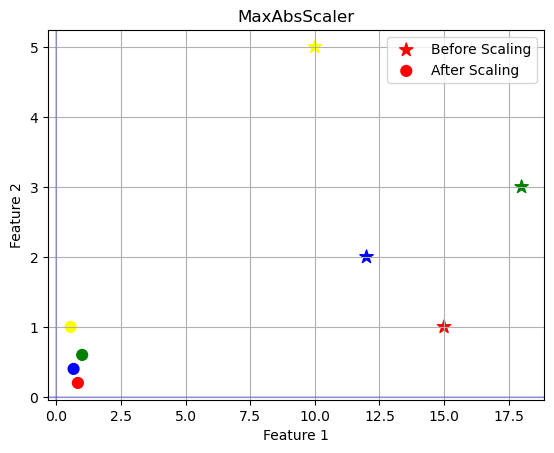

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
colors = ['red','green','blue','yellow']
ax.scatter(x=df.f1, y=df.f2, label="Before Scaling", color=colors, marker = '*',s=100)
ax.scatter(x=df2.f1, y=df2.f2, label="After Scaling", color=colors, marker = 'o',s=60)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.title("MaxAbsScaler")
plt.legend(loc='best')
plt.axhline(0, color='blue',alpha=0.2)
plt.axvline(0, color='blue',alpha=0.2);
plt.grid(True)

## b. `MinMaxScalar` 
- The `MinMaxScalar` scales and translates the feature values such that they fall in the range of [0,1] . If there are negative values, it shrinks the data within the range of [-1,1]. 

$$\large x_i’ = \large \frac{x_i - min(x)}{max(x)-min(x)}$$

- When the value of $x_i$ is the minimum value in the column, the numerator will be 0, and hence $x_i'$ will be 0
- On the other hand, when the value of $x_i$ is the maximum value in the column, the numerator is equal to the denominator and thus the value of $x_i'$ will be 1
- If the value of $x_i$ is between the minimum and the maximum value, then the value of $x_i'$ will be between 0 and 1
>- This Scaler responds well if the standard deviation is small and when a distribution is not Gaussian. This Scaler is sensitive to outliers.

In [7]:
df

,f1,f2
0,15,1
1,18,3
2,12,2
3,10,5


### Using NumPy

In [8]:
f1_minmax = [(x-np.min(df.f1))/(np.max(df.f1) - np.min(df.f1)) for x in df.f1]
f2_minmax = [(x-np.min(df.f2))/(np.max(df.f2) - np.min(df.f2)) for x in df.f2]
df1 = pd.DataFrame({'f1': f1_minmax, 'f2': f2_minmax})
df1

,f1,f2
0,0.625,0.00
1,1.000,0.50
2,0.250,0.25
3,0.000,1.00


### Using `MinMaxScaler` Transformer

In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
arr = scaler.fit_transform(df)
df2 = pd.DataFrame(arr, columns=['f1','f2'])
df2

,f1,f2
0,0.625,0.00
1,1.000,0.50
2,0.250,0.25
3,0.000,1.00


### Visualize Data Before and After Scaling

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
colors = ['red','green','blue','yellow']
ax.scatter(x=df.f1, y=df.f2, label="Before Scaling", color=colors, marker = '*',s=100)
ax.scatter(x=df2.f1, y=df2.f2, label="After Scaling", color=colors, marker = 'o',s=60)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.title("MinMaxScaler")
plt.legend(loc='best')
plt.axhline(0, color='blue',alpha=0.2)
plt.axvline(0, color='blue',alpha=0.2);
plt.grid(True)

## c. `StandardScalar`
- StandardScaler is the industry’s go-to algorithm 🙂 
- It rescales the data from original range, so that all values are centered around the mean of zero with a standard deviation of one.
- StandardScalar assumes that you are working with normally distributed data and the outliers are not too crazy

$$\large Z_i = x_i’ = \large \frac{x_i - \mu}{\sigma}$$

- `Note:` The values are not restricted to a particular range, although majority will fall within $1\sigma$ around mean

In [ ]:
df

### Using NumPy

In [10]:
f1_std = [(x-np.mean(df.f1))/(np.std(df.f1)) for x in df.f1]
f2_std = [(x-np.mean(df.f2))/(np.std(df.f2)) for x in df.f2]
df1 = pd.DataFrame({'f1': f1_std, 'f2': f2_std})
df1

,f1,f2
0,0.412393,-1.183216
1,1.402136,0.169031
2,-0.577350,-0.507093
3,-1.237179,1.521278


### Using `StandardScaler` Transformer

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
arr = scaler.fit_transform(df)
df2 = pd.DataFrame(arr, columns=['f1','f2'])
df2

,f1,f2
0,0.412393,-1.183216
1,1.402136,0.169031
2,-0.577350,-0.507093
3,-1.237179,1.521278


In [12]:
df2.f1.mean()

5.551115123125783e-17

### Visualize Data Before and After Scaling

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
colors = ['red','green','blue','yellow']
ax.scatter(x=df.f1, y=df.f2, label="Before Scaling", color=colors, marker = '*',s=100)
ax.scatter(x=df2.f1, y=df2.f2, label="After Scaling", color=colors, marker = 'o',s=60)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.title("StandardScaler")
plt.legend(loc='best')
plt.axhline(0, color='blue',alpha=0.2)
plt.axvline(0, color='blue',alpha=0.2);
plt.grid(True)

## d. `RobustScalar`
- As the name suggests, this Scaler is robust to outliers. 
- Outliers can skew a probability distribution and make data scaling using standardization difficult as the calculated **mean and standard deviation will be skewed by the presence of the outliers.**
- Instead of subtracting the mean, you subtract data values from the median (50th percentile), and instead of dividing by the standard deviation, you divide by Inter Quartile Range (IQR).  
- The formula to scale using Robust Scalar using quartiles:
$$\large x_i’ = \large \frac{x_i - Q_2(x)}{Q_3(x) - Q_1(x)}$$

- The formula to scale using Robust Scalar using percentiles:
$$\large x_i' = \frac{x_i – Median}{P_{75} – P_{25}}$$

- The resulting variable will have a zero mean and median and a standard deviation of 1, although not skewed by outliers and the outliers are still present with the same relative relationships to other values.

In [ ]:
df

### Using NumPy

In [ ]:
f1_robust = [(x-df.f1.quantile(0.50))/(df.f1.quantile(0.75) - df.f1.quantile(0.25)) for x in df.f1]
f2_robust = [(x-df.f2.quantile(0.50))/(df.f2.quantile(0.75) - df.f2.quantile(0.25)) for x in df.f2]
df1 = pd.DataFrame({'f1': f1_robust, 'f2': f2_robust})
df1

### Using `RobustScaler` Transformer

In [ ]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
arr = scaler.fit_transform(df)
df2 = pd.DataFrame(arr, columns=['f1','f2'])
df2

### Visualizing Data Before and After Scaling

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
colors = ['red','green','blue','yellow']
ax.scatter(x=df.f1, y=df.f2, label="Before Scaling", color=colors, marker = '*',s=100)
ax.scatter(x=df2.f1, y=df2.f2, label="After Scaling", color=colors, marker = 'o',s=60)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.title("RobustScaler")
plt.legend(loc='best')
plt.axhline(0, color='blue',alpha=0.2)
plt.axvline(0, color='blue',alpha=0.2);
plt.grid(True)

## e. Comparison

<img align="center" width="1000" src="images/comparison-scalars1.png"  >

## f. Effect of Outliers in the Distribution

**Import Libraries:**

In [13]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns 
matplotlib.style.use('fivethirtyeight')

**Create synthetic dataset:**

In [14]:
# Input Feature with lower outliers (1000 values with a mean of )
arr1 = np.concatenate([np.random.normal(loc=20, scale=2, size=1000), np.random.normal(loc=1, scale=2, size=25)])
# Input Feature with higher outliers
arr2 = np.concatenate([np.random.normal(loc=40, scale=2, size=1000), np.random.normal(loc=70, scale=2, size=25)])
df = pd.DataFrame({'f1': arr1,'f2': arr2})
df

,f1,f2
0,20.775900,38.497291
1,17.945257,40.447157
2,21.883311,42.295975
3,16.165465,38.084696
4,21.381038,38.962157
...,...,...
1020,1.336110,71.103113
1021,-0.013440,69.025217
1022,-0.698553,72.272227
1023,-0.143517,70.729255


**Visualize Distribution of the two feature columns:**

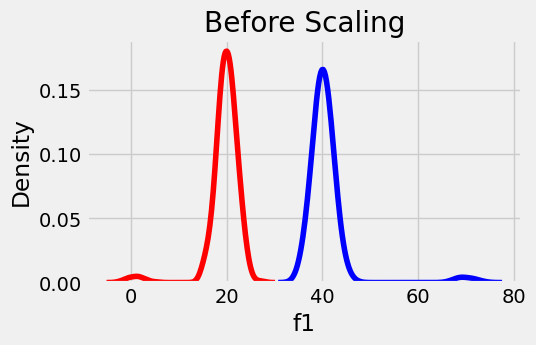

In [15]:
fig, ax = plt.subplots(figsize =(5, 3))
ax.set_title('Before Scaling')
sns.kdeplot(df['f1'], color ='r')
sns.kdeplot(df['f2'], color ='b')
plt.show()

>- Observe feature 1 (red) has a mean of 20, while the outliers in feature 1 (red) are around a mean of 1
>- Observe feature 2 (blue) has a mean of 40, while the outliers in feature 2 (blue) are around a mean of 70

**Perform Scaled Dataframes using MinMaxScaler, StandardScaler, and RobustScaler:**

In [16]:
scaler = preprocessing.MinMaxScaler()
minmax_df = scaler.fit_transform(df)
minmax_df = pd.DataFrame(minmax_df, columns =['f1', 'f2'])

scaler = preprocessing.StandardScaler()
standard_df = scaler.fit_transform(df)
standard_df = pd.DataFrame(standard_df, columns =['f1', 'f2'])

scaler = preprocessing.RobustScaler()
robust_df = scaler.fit_transform(df)
robust_df = pd.DataFrame(robust_df, columns =['f1', 'f2'])

**Visualize Distributions before and after Scaling:**

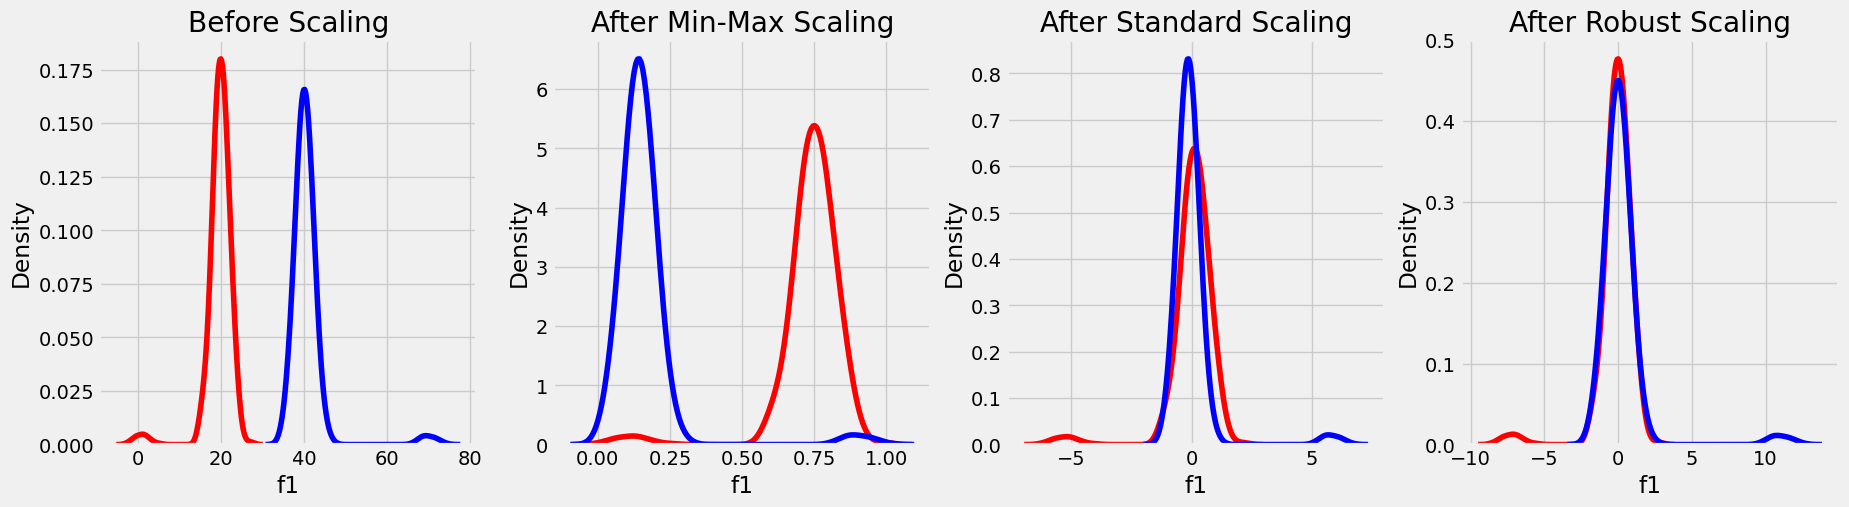

In [17]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(ncols = 4, figsize =(20, 5))
ax1.set_title('Before Scaling')
sns.kdeplot(df['f1'], ax = ax1, color ='r')
sns.kdeplot(df['f2'], ax = ax1, color ='b')

ax2.set_title('After Min-Max Scaling')
sns.kdeplot(minmax_df['f1'], ax = ax2, color ='r')
sns.kdeplot(minmax_df['f2'], ax = ax2, color ='b')

ax3.set_title('After Standard Scaling')
sns.kdeplot(standard_df['f1'], ax = ax3, color ='r')
sns.kdeplot(standard_df['f2'], ax = ax3, color ='b')

ax4.set_title('After Robust Scaling')
sns.kdeplot(robust_df['f1'], ax = ax4, color ='r')
sns.kdeplot(robust_df['f2'], ax = ax4, color ='b')

plt.show()

# 3. Perform Scaling on a Real Dataset for ML Task 
- It is always a better approach to train-test-split first and then do the scaling so that there is no data leakage.
- So you `fit_transform()` on the train data, then only transform on the test data.
- Almost all feature engineering like missing value imputation, encoding of categorical data, feature scaling etc should be done after train-test-split.

## a. Load Dataset

In [18]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns 
matplotlib.style.use('fivethirtyeight')
df = pd.read_csv('datasets/scaling-data1.csv')
df

,age,salary,target
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [19]:
df.describe()

,age,salary,target
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     400 non-null    int64
 1   salary  400 non-null    int64
 2   target  400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


## b. Do a Train-Test-Split

In [21]:
X = df.drop('target', axis=1)
X

,age,salary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [22]:
y = df['target']
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: target, Length: 400, dtype: int64

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=54)
len(X_train), len(y_train), len(X_test), len(y_test)

(320, 320, 80, 80)

In [24]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((320, 2), (80, 2), (320,), (80,))

In [25]:
X_train.head()

,age,salary
333,40,65000
273,39,106000
307,47,113000
4,19,76000
292,55,39000


In [26]:
y_train.head()

333    0
273    1
307    1
4      0
292    1
Name: target, dtype: int64

In [27]:
X_test.head()

,age,salary
346,53,72000
178,24,23000
251,37,52000
228,40,72000
179,31,34000


In [28]:
y_test.head()

346    1
178    0
251    0
228    0
179    0
Name: target, dtype: int64

## c. Apply `StandardScaler` to `age` and `salary` Columns

In [29]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
ss.fit(X_train[['age','salary']])

# transform train and test sets
X_train_scaled = ss.transform(X_train[['age','salary']])
X_test_scaled = ss.transform(X_test[['age','salary']])

X_train_scaled.shape, X_test_scaled.shape

((320, 2), (80, 2))

In [30]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, MaxAbsScaler

In [31]:
# convert the two numPy arrays to Pandas dataframes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [32]:
X_train_scaled

,age,salary
0,0.226798,-0.160423
1,0.132176,1.040916
2,0.889155,1.246022
3,-1.760273,0.161888
4,1.646135,-0.922247
...,...,...
315,0.699910,-1.420363
316,2.024624,0.161888
317,1.078400,-0.922247
318,0.321421,-0.306927


In [33]:
X_test_scaled

,age,salary
0,1.456890,0.044684
1,-1.287161,-1.391062
2,-0.057069,-0.541335
3,0.226798,0.044684
4,-0.624804,-1.068751
...,...,...
75,0.226798,-0.394830
76,-0.246314,0.132587
77,0.037553,-0.599937
78,0.416043,-0.482733


In [34]:
np.round(X_train_scaled.describe(), 2) #rounding the values for better visualization

,age,salary
count,320.00,320.00
mean,0.00,-0.00
std,1.00,1.00
min,-1.85,-1.63
25%,-0.81,-0.78
50%,-0.06,-0.03
75%,0.79,0.51
max,2.12,2.33


In [35]:
np.round(X_test_scaled.describe(), 2) #rounding the values for better visualization

,age,salary
count,80.00,80.00
mean,0.02,-0.11
std,0.96,0.99
min,-1.85,-1.63
25%,-0.72,-0.95
50%,0.04,-0.01
75%,0.42,0.32
max,2.12,2.30


## d. Visualize Distribution Before and After Scaling

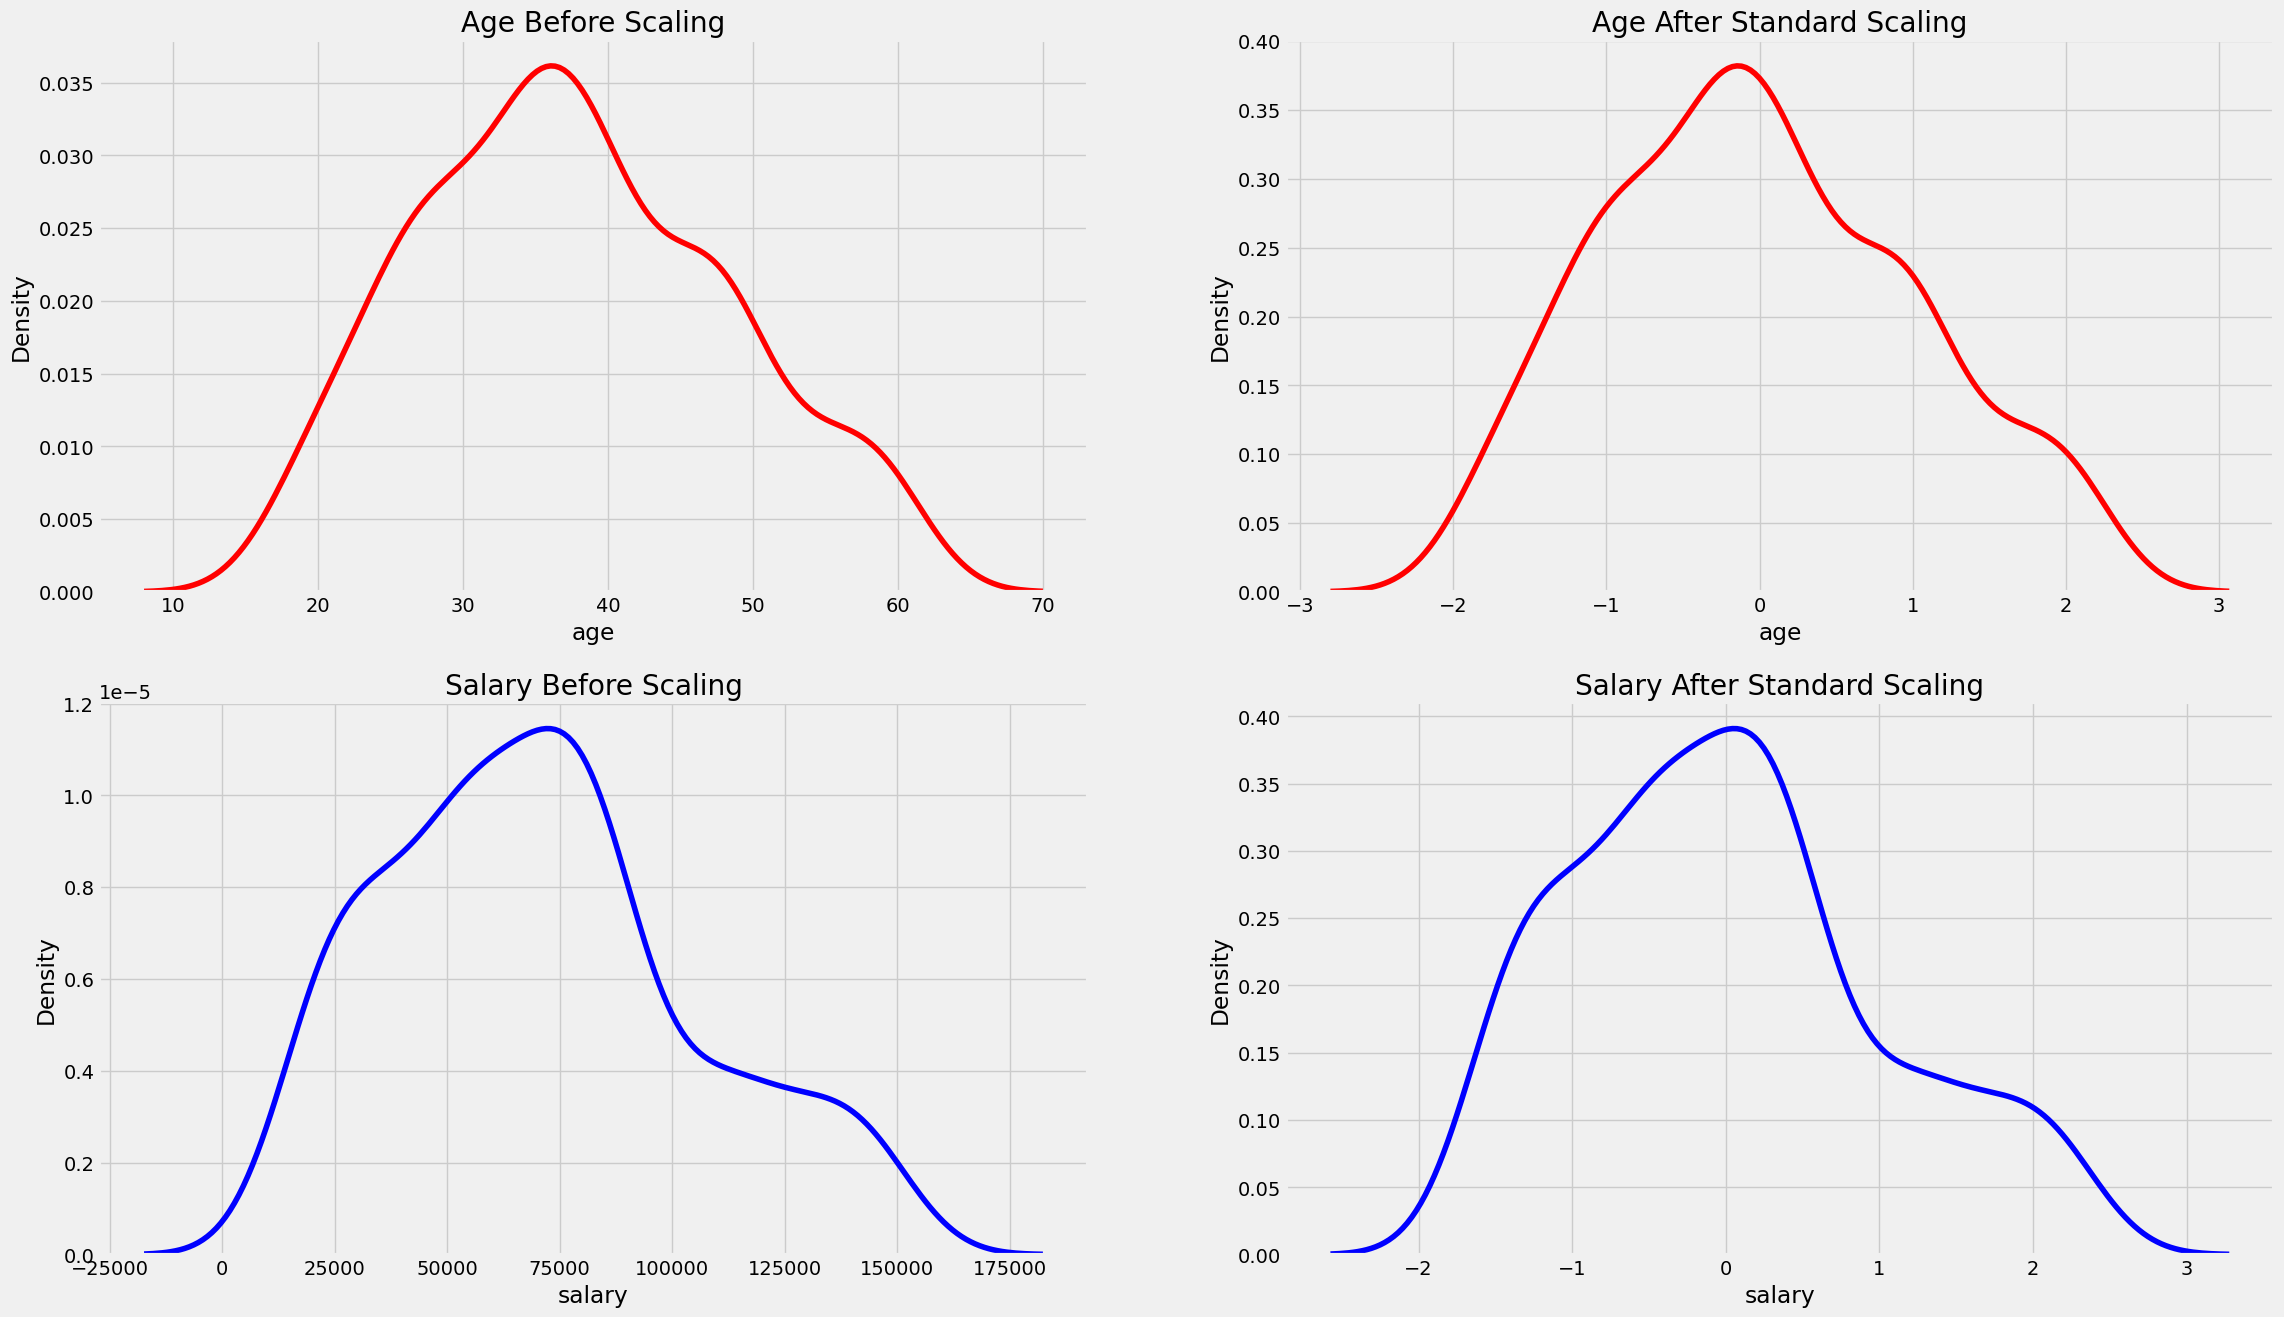

In [36]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols = 2, figsize =(25, 15))
# age before scaling
ax1.set_title('Age Before Scaling')
sns.kdeplot(X_train['age'], ax=ax1, color ='red')

# age after scaling
ax2.set_title('Age After Standard Scaling')
sns.kdeplot(X_train_scaled['age'], ax=ax2, color ='red')

# salary before scaling
ax3.set_title('Salary Before Scaling')
sns.kdeplot(X_train['salary'], ax=ax3, color ='blue')

# salary after scaling
ax4.set_title('Salary After Standard Scaling')
sns.kdeplot(X_train_scaled['salary'], ax=ax4, color ='blue')
plt.show()